# 🍷 Predicción de la Calidad del Vino (Rojo y Blanco) - Proceso KDD

**Nombre y apellidos: Pablo Sáez Gil**

## 1️⃣ Goal - Objetivo del Proyecto

El objetivo de este proyecto es **predecir la calidad de vinos tintos y blancos** clasificándolos como:
- **Bueno**: si la calidad es **superior a 5**,
- **Malo**: si la calidad es **5 o inferior**.

Se sigue un enfoque estructurado basado en el **proceso KDD (Knowledge Discovery in Databases)**, incluyendo las siguientes etapas clave:

✅ **Selección de Datos**: Carga y unión de los datasets de vinos tintos y blancos.

✅ **Preprocesamiento**: Limpieza de datos mediante eliminación de duplicados y tratamiento de valores extremos (outliers).

✅ **Transformación**: Estandarización y codificación de variables para preparar los datos de manera adecuada para el modelado.

✅ **Minería de Datos**: Entrenamiento de modelos predictivos, principalmente utilizando Random Forest, para clasificar los vinos según su calidad.

✅ **Evaluación e Interpretación**: Análisis del rendimiento mediante métricas (accuracy, recall, f1-score), matrices de confusión y visualizaciones (curvas ROC, Precision-Recall y PCA).

📌 **Dataset combinado**: aproximadamente **6,500 registros** provenientes de los vinos tintos y blancos del repositorio UCI.

Este enfoque permite una **visión completa del proceso analítico**, desde la recopilación de datos hasta la evaluación e interpretación de resultados, siguiendo las buenas prácticas de minería de datos.

# 1️⃣ Selección de Datos


## Librerías Utilizadas

A continuación se importan las principales librerías necesarias para la correcta ejecución del proyecto, abarcando todas las fases del proceso KDD:

- ✅ **`pandas`**: para la manipulación y análisis de datos tabulares.
- ✅ **`numpy`**: para operaciones matemáticas y de arrays.
- ✅ **`matplotlib.pyplot`** y **`seaborn`**: para crear visualizaciones gráficas descriptivas y avanzadas.
- ✅ **`train_test_split` y `StandardScaler`** de `sklearn`: para la división y normalización de datos durante el preprocesamiento.
- ✅ **`RandomForestClassifier`**: modelo principal utilizado para la clasificación supervisada.
- ✅ **`classification_report` y `confusion_matrix`**: evaluación numérica de las predicciones.
- ✅ **`PCA (Análisis de Componentes Principales)`**: para reducción de dimensionalidad y visualización en 2D.
- ✅ **`roc_curve`, `precision_recall_curve`, `auc`**: para generación de curvas ROC y Precision-Recall.
- ✅ **`LabelEncoder`**: para convertir etiquetas categóricas a formato numérico durante evaluaciones.

Estas librerías permiten implementar un flujo completo y estructurado desde la carga de datos hasta el análisis avanzado de resultados y visualizaciones.


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.decomposition import PCA
from sklearn.metrics import roc_curve, precision_recall_curve, auc
from sklearn.preprocessing import LabelEncoder

## Carga y Unión de Datos

En esta sección realizamos la **selección y combinación de los datos** provenientes de dos fuentes diferentes del conjunto de datos de vinos del repositorio UCI:

- ✅ **`winequality-red.csv`**: contiene datos de vinos tintos.
- ✅ **`winequality-white.csv`**: contiene datos de vinos blancos.

Pasos aplicados:
- Se cargan ambos datasets por separado utilizando `pandas.read_csv()`.
- Se crea una nueva columna llamada **`type`** para distinguir entre **vino tinto** y **vino blanco**.
- Finalmente, ambos datasets se **concatenan** en un único dataframe llamado `data` que reúne toda la información disponible.

Este paso asegura que podamos trabajar con un **dataset unificado y etiquetado** que permita un análisis más completo y comparaciones entre tipos de vino.

In [18]:
# Cargar datasets
url_red = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
url_white = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-white.csv"

red = pd.read_csv(url_red, sep=';')
white = pd.read_csv(url_white, sep=';')

# Añadir columna de tipo de vino
red["type"] = "red"
white["type"] = "white"

# Unir datasets
data = pd.concat([red, white], axis=0).reset_index(drop=True)
print("Total de registros del data:", data.shape[0])
data.head()

Total de registros del data: 6497


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


## Información del Dataset

Utilizamos el método **`data.info()`** para obtener una visión general del dataframe:

- 📌 **Número total de registros** y **columnas** presentes en el dataset.
- 📌 **Tipo de dato** de cada columna (numérico, objeto, etc.).
- 📌 Cantidad de **valores no nulos** en cada columna para detectar posibles **valores faltantes**.

Este análisis rápido nos permite:
- Comprobar si es necesario aplicar limpieza adicional,
- Verificar que la unión de datos ha sido exitosa,
- Confirmar la consistencia y completitud de los datos antes de proceder a transformaciones o modelado.


In [19]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


## Estadísticas Descriptivas

Con **`data.describe()`** obtenemos un resumen estadístico de todas las variables numéricas del dataset:

- ✅ **Media**, **desviación estándar**, **mínimo** y **máximo** de cada variable.
- ✅ **Percentiles (25%, 50%, 75%)**, que nos permiten observar la dispersión y distribución de los datos.
- ✅ Detectamos posibles **outliers** cuando los valores máximos o mínimos se alejan mucho de los percentiles intermedios.

Este análisis es esencial para:
- Entender la **distribución general de los datos**,
- Identificar posibles **valores atípicos**,
- Tener un primer acercamiento a la **escala y rango** de cada característica antes de aplicar preprocesamiento.


In [20]:
#Descripción de los datos
data.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000,6497.000000
mean,7.215307,0.339666,0.318633,5.443235,0.056034,30.525319,115.744574,0.994697,3.218501,0.531268,10.491801,5.818378
std,1.296434,0.164636,0.145318,4.757804,0.035034,17.749400,56.521855,0.002999,0.160787,0.148806,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


# 2️⃣ Preprocesamiento

## Creación de Etiqueta Binaria

En esta etapa generamos una **variable objetivo binaria** llamada `quality_label`:

- ✅ Se clasifica cada registro como:
   - **`bueno`** si la puntuación de calidad es superior a 5,
   - **`malo`** si es igual o inferior a 5.
- ✅ Se utiliza la función `apply()` para recorrer cada valor de la columna original `quality` y transformarlo.

Este cambio facilita la tarea de **clasificación binaria**, simplificando el análisis y mejorando la interpretabilidad del modelo respecto a un escenario multiclase.
Generamos la columna que utilizaremos como objetivo/target, la denominaremos como quality_label. La cual recogerá como bueno o malo la calidad del vino.

In [21]:
# Clasificación binaria
data['quality_label'] = data['quality'].apply(lambda x: 'bueno' if x > 5 else 'malo')

## Detección y Eliminación de Duplicados

En este paso verificamos la presencia de registros duplicados en el dataset y los eliminamos para evitar que afecten el modelo.

- ✅ Con `data.duplicated().sum()` comprobamos cuántos registros son duplicados.
- ✅ Utilizamos `data.drop_duplicates()` para **eliminar filas repetidas**, garantizando que cada muestra en el dataset sea única.

Este proceso es importante para:
- Evitar **sobreajuste** del modelo debido a datos redundantes.
- Mantener la **calidad y representatividad** del dataset durante el entrenamiento.


In [22]:
# Verificar duplicados
print("Datos duplicados:", data.duplicated().sum())

# Eliminar duplicados
data = data.drop_duplicates()

Datos duplicados: 1177


## Detección de Valores Nulos

Antes de continuar con la limpieza y modelado, verificamos la existencia de **valores nulos o faltantes** en el dataset.

- ✅ Utilizamos `data.isnull().sum()` para contar el número de valores nulos en cada columna.
- ✅ Esto nos ayuda a identificar posibles **problemas de calidad de datos**.

Dependiendo del resultado, se podrían aplicar estrategias de:
- Imputación de datos,
- Eliminación de filas o columnas,
- O simplemente confirmar que no existen valores nulos y el dataset está limpio.


In [23]:
# Verificar duplicados
print("Datos nulos:\n" ,data.isnull().sum())

Datos nulos:
 fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
quality_label           0
dtype: int64


## Análisis Gráfico del Balance de Clases

Para entender la distribución de clases en nuestro dataset, realizamos un análisis gráfico y numérico de la variable objetivo `quality_label`:

- ✅ Utilizamos un **`countplot`** para visualizar la **cantidad de registros** en cada categoría (`bueno` y `malo`), observando si existe un desbalance.
- ✅ Calculamos la **proporción relativa** de cada clase con `value_counts(normalize=True)` para tener una visión porcentual.

Este análisis es clave porque:
- Un **desbalance severo** podría afectar negativamente el rendimiento del modelo,
- Nos ayuda a decidir si será necesario aplicar técnicas de **balanceo de clases** (como `class_weight`, sobremuestreo o submuestreo),
- Proporciona una comprensión inicial del sesgo potencial en los datos.


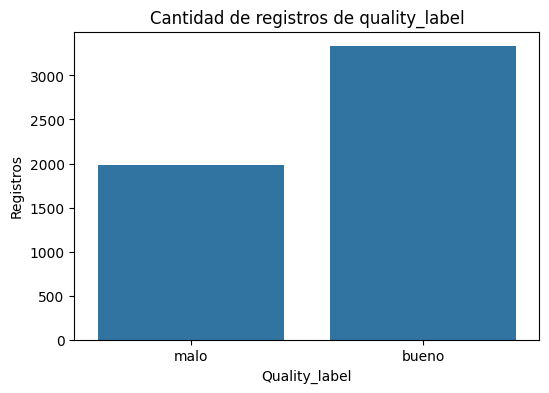

La proporción de registros es:  quality_label
bueno    0.626316
malo     0.373684
Name: proportion, dtype: float64


In [24]:
# Generamos un gráfico para comparar registros
plt.figure(figsize=(6, 4))
sns.countplot(x="quality_label", data=data)
plt.xlabel("Quality_label")
plt.ylabel("Registros")
plt.title("Cantidad de registros de quality_label")
plt.show()

# Calculamos la proporción de valores
print("La proporción de registros es: ", data['quality_label'].value_counts(normalize=True))

### Análisis del Balance de Clases - `quality_label`

La gráfica muestra la distribución de registros según la variable objetivo `quality_label`, diferenciando entre vinos clasificados como **`bueno`** y **`malo`**.

**Observaciones clave:**
- ✅ Existe un **desbalance de clases moderado**:
   - Aproximadamente **⅔ de los registros son vinos “buenos”**,
   - Mientras que **⅓ corresponde a vinos “malos”**.
- 📌 Esta proporción podría influir en el modelo, favoreciendo predicciones hacia la clase mayoritaria (“bueno”).

**Conclusiones:**
- Aunque no es un desbalance extremo, es recomendable:
   - Aplicar métodos para **tener en cuenta el desbalance**, como:
     - ✅ Usar `class_weight='balanced'` en modelos como Random Forest o Logistic Regression,
     - ✅ Evaluar métricas sensibles al desbalance como el **recall** o el **f1-score**,
     - ✅ Analizar curvas ROC o ajustar umbrales si fuera necesario.
- 📌 En este proyecto, se optó por utilizar técnicas que compensan parcialmente este desbalance para garantizar una predicción más justa para ambas clases.



# 3️⃣ Transformación

## Análisis de Outliers con Diagramas de Caja

Para detectar y visualizar la presencia de **outliers** en las variables numéricas, generamos **diagramas de caja** (`boxplots`) para cada una de ellas:

- ✅ Se recorren todas las columnas numéricas del dataset utilizando `select_dtypes()`.
- ✅ Se genera un gráfico por variable mostrando:
   - La **distribución** de los datos,
   - La **mediana**,
   - Los **cuartiles**,
   - Y los **valores extremos (outliers)** que aparecen como puntos fuera del rango intercuartílico.

Este análisis es fundamental porque:
- Nos ayuda a identificar **variables con valores extremos significativos**,
- Facilita la **decisión sobre tratamiento de outliers** (eliminación o imputación),
- Mejora la **calidad del preprocesamiento** al tratar los datos de forma más robusta antes de modelar.


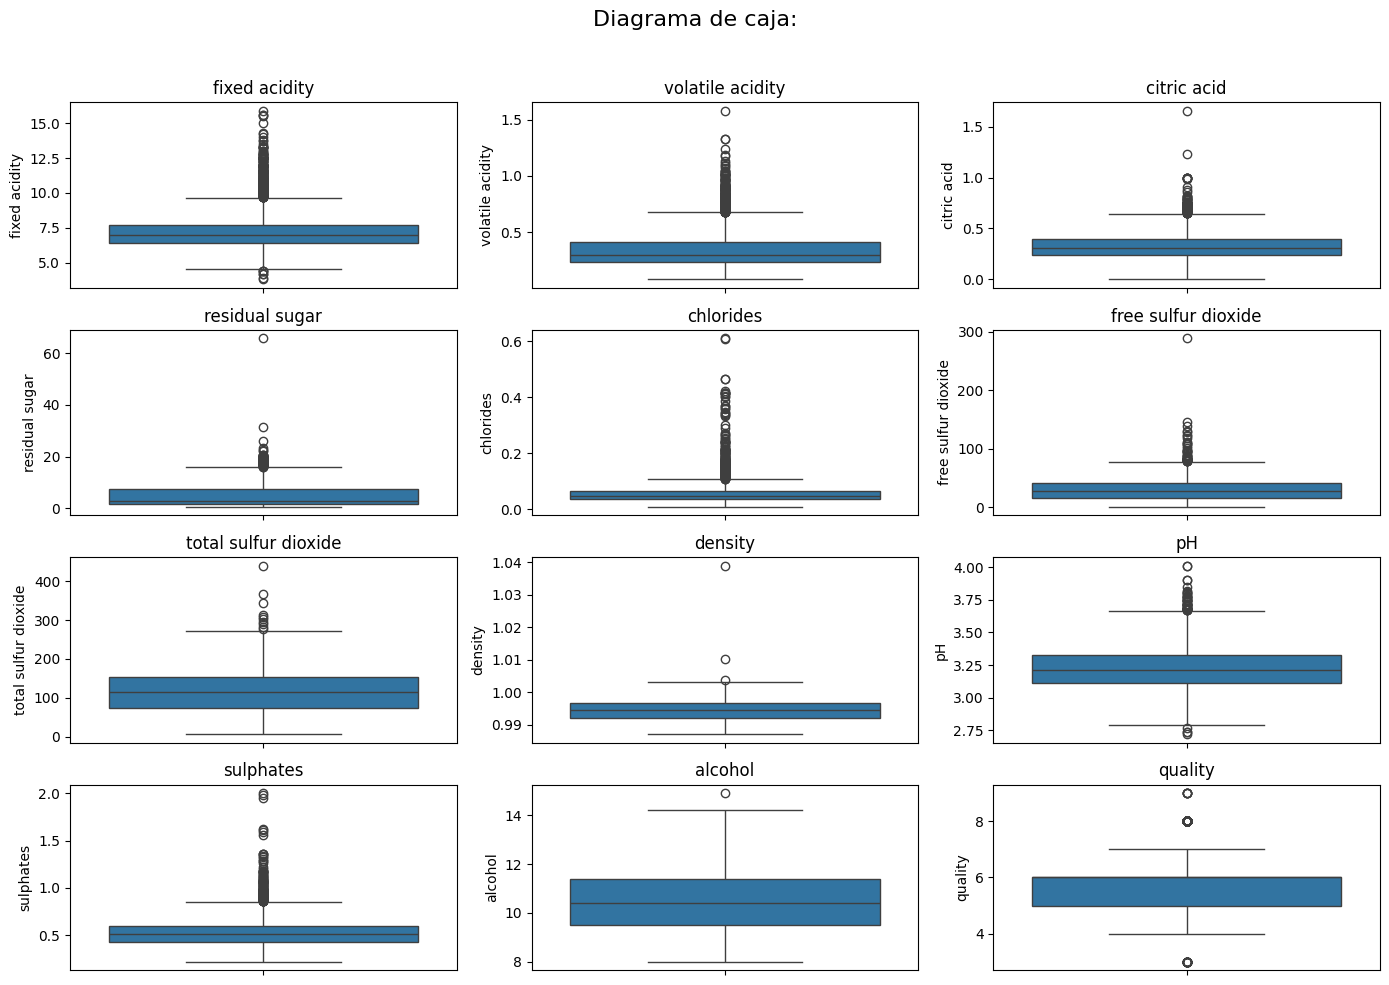

In [25]:
plt.figure(figsize=(14, 10))
for i, col in enumerate(data.select_dtypes(include='number').columns):
    plt.subplot(4, 3, i+1)
    sns.boxplot(y=data[col])
    plt.title(col)
plt.suptitle("Diagrama de caja:", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Observación de Outliers a través de Diagramas de Caja

A partir del análisis gráfico con diagramas de caja, observamos lo siguiente:

- ✅ La mayoría de variables presentan **outliers** detectables visualmente, indicados por puntos situados fuera de los bigotes del boxplot.
- 🔵 Variables como `residual sugar`, `free sulfur dioxide`, `total sulfur dioxide` y `sulphates` muestran una **concentración importante de valores extremos**.
- 🔵 Algunas variables como `density`, `fixed acidity` y `alcohol` presentan **outliers más moderados**.
- 📌 La variable objetivo `quality` también muestra dispersión, aunque con menor frecuencia de valores extremos.

**Interpretación:**
- La presencia de outliers es **esperable en datos reales** como los de vinos, debido a variaciones naturales en el proceso de producción.
- Sin embargo, los outliers más extremos pueden distorsionar la media y afectar a modelos sensibles (como regresiones), por lo que es importante considerar un **tratamiento de outliers** previo al modelado.

**Decisión tomada en el proyecto:**
- Se aplicó una **eliminación controlada de outliers** mediante el método IQR ampliado (±3*IQR), conservando la mayor parte de datos relevantes pero eliminando valores excesivamente extremos.


## Eliminación de Outliers con IQR Extendido

En esta sección definimos y aplicamos una **función personalizada** para eliminar **outliers extremos** utilizando el método **IQR (rango intercuartílico)**:

- ✅ Se calculan los **percentiles 25% (Q1)** y **75% (Q3)** para cada variable numérica.
- ✅ Se determina el **rango intercuartílico (IQR = Q3 - Q1)**.
- ✅ Se definen los **límites extremos** utilizando **3 * IQR** (criterio más flexible que el estándar de 1.5 * IQR) para eliminar únicamente los valores realmente anómalos.
- ✅ Se filtran los datos manteniendo únicamente los registros que se encuentran dentro de estos límites.

Este enfoque:
- 📌 **Minimiza el impacto de valores extremos severos**,
- 📌 Mejora la **robustez del modelo** al eliminar registros que podrían distorsionar el aprendizaje,
- 📌 Mantiene suficiente cantidad de datos útiles al aplicar un criterio de outliers menos restrictivo que el tradicional.

Finalmente, se imprime la cantidad de registros restantes después de la limpieza.


In [26]:
# Función para limpiar outliers
def eliminar_outliers_iqr(df, columnas):
    for col in columnas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lim_inf = Q1 - 3 * IQR
        lim_sup = Q3 + 3 * IQR
        df = df[(df[col] >= lim_inf) & (df[col] <= lim_sup)]
    return df

# Limpiar
columnas_numericas = data.select_dtypes(include='number').columns[:-1]
data = eliminar_outliers_iqr(data, columnas_numericas)
print("Registros después de limpiar outliers:", len(data))


Registros después de limpiar outliers: 5047


## Comprobación Gráfica Tras Eliminación de Outliers

Después de aplicar la limpieza de outliers mediante el método IQR, generamos nuevamente **diagramas de caja (boxplots)** para las variables numéricas:

- ✅ Se visualiza la **distribución de los datos** después de eliminar los registros anómalos.
- ✅ Esta gráfica permite verificar si la limpieza fue efectiva y observar cómo se ha **reducido la presencia de valores extremos**.
- ✅ Se genera un boxplot individual para cada variable numérica, mostrando la **mediana**, **rango intercuartílico**, y cualquier punto atípico residual.

Este análisis visual confirma:
- 📌 Una **distribución más limpia y consistente** de las variables,
- 📌 La eficacia del tratamiento aplicado a los outliers,
- 📌 La preparación adecuada de los datos para ser usados en modelos predictivos posteriores.


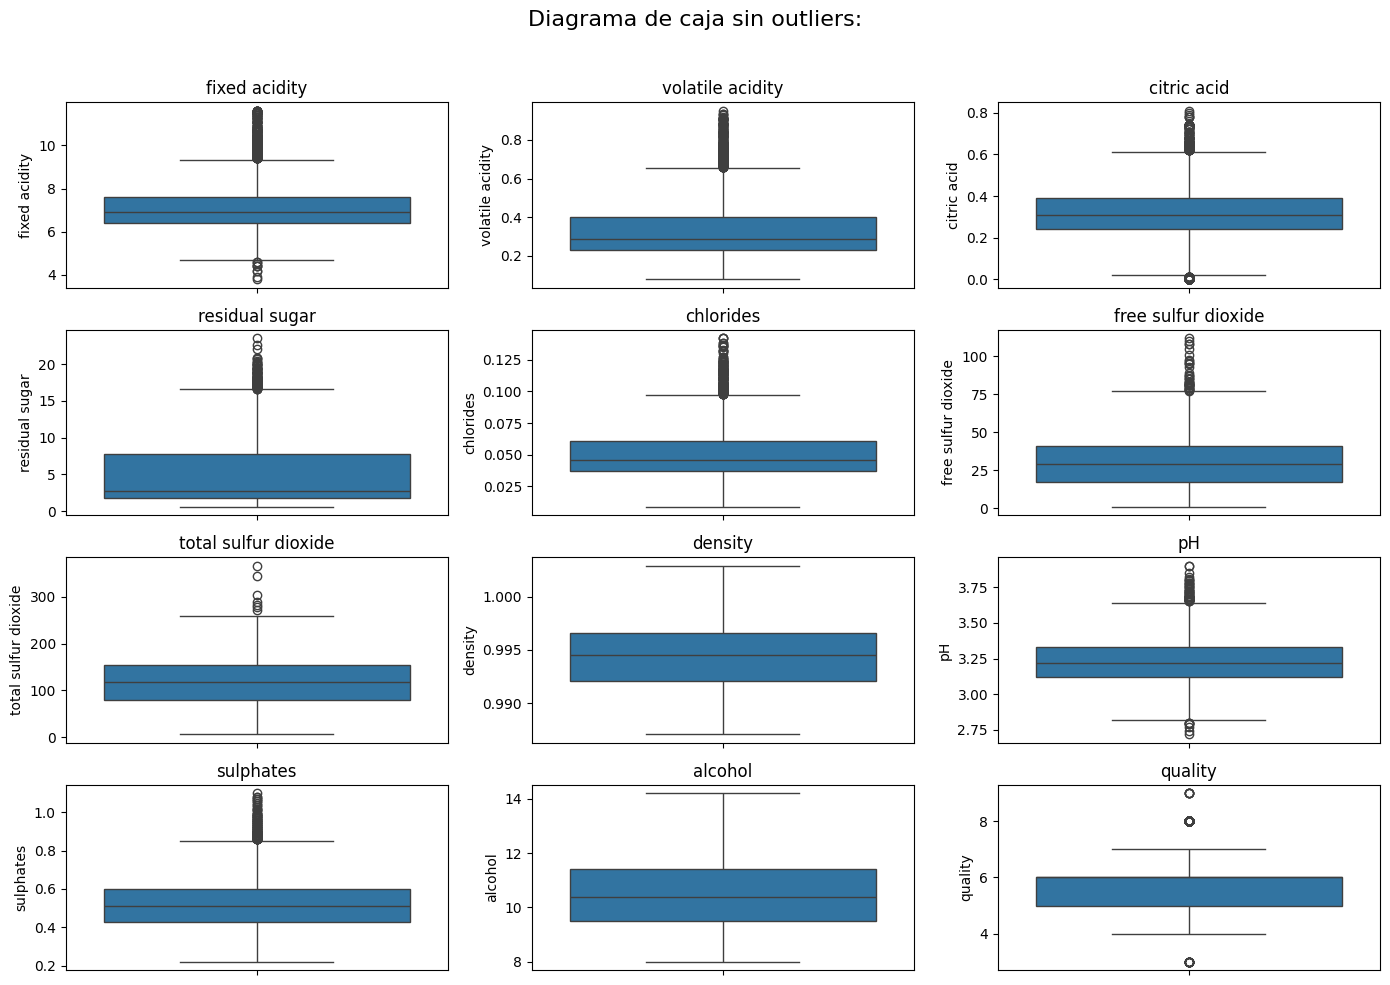

In [27]:
plt.figure(figsize=(14, 10))
for i, col in enumerate(data.select_dtypes(include='number').columns):
    plt.subplot(4, 3, i+1)
    sns.boxplot(y=data[col])
    plt.title(col)
plt.suptitle("Diagrama de caja sin outliers:", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

### Comparativa tras Eliminación de Outliers

La gráfica muestra los **diagramas de caja después de aplicar el tratamiento de outliers** utilizando el método IQR ampliado (±3*IQR).

**Observaciones clave:**
- ✅ Se observa una **disminución significativa de los valores extremos** en prácticamente todas las variables numéricas.
- ✅ La distribución se mantiene más **centrada y homogénea**, con rangos más consistentes entre el cuartil inferior y superior.
- ✅ Variables como `residual sugar`, `free sulfur dioxide` y `total sulfur dioxide` siguen mostrando cierta dispersión natural, pero sin presencia de valores anómalos extremos como antes.
- 📌 Variables como `density` y `alcohol` reflejan ahora una distribución mucho más compacta, confirmando el efecto del preprocesamiento.

**Conclusión:**
- El tratamiento de outliers ha conseguido **limpiar adecuadamente los valores extremos** sin eliminar información relevante,
- Esto permite mejorar la **robustez de los modelos predictivos**, evitando que valores atípicos distorsionen el aprendizaje.
- Visualmente se constata una mejora en la **calidad del dataset para modelado**.


## División y Transformación de Datos

En este paso preparamos los datos para el entrenamiento del modelo:

- ✅ **Separación de variables independientes (X)** y la **variable objetivo (y)**.
   - Se eliminan las columnas `quality` (numérica) y `quality_label` (objetivo binario) de X.
   - Se utiliza `pd.get_dummies()` para convertir la variable categórica `type` (vino blanco o tinto) en variables numéricas mediante **codificación One-Hot**.
- ✅ Se realiza un **train/test split**:
   - 80% de los datos se destinan al entrenamiento y 20% al test,
   - Se utiliza `stratify=y` para mantener la proporción de clases en ambos conjuntos,
   - `random_state=42` asegura reproducibilidad de resultados.
- ✅ **Estandarización de variables numéricas**:
   - Aplicamos `StandardScaler` para escalar las variables a media 0 y desviación estándar 1,
   - Esto es especialmente útil para algoritmos sensibles a la escala de los datos.

Este preprocesamiento garantiza que el modelo trabaje con datos **normalizados**, **numéricos** y con una distribución consistente entre entrenamiento y prueba.


In [28]:
X = data.drop(['quality', 'quality_label'], axis=1)
X = pd.get_dummies(X, columns=['type'], drop_first=True)  # Codificar tipo de vino
y = data['quality_label']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4️⃣ Minería de Datos

## Modelo Random Forest

En esta sección aplicamos un **modelo de Random Forest**, un algoritmo muy utilizado en clasificación debido a su capacidad para manejar datasets con muchas variables y su resistencia al sobreajuste.

El modelo se entrena con:
- ✅ **100 árboles** (`n_estimators=100`), lo que proporciona una estimación robusta.
- ✅ **`random_state=42`** para garantizar reproducibilidad.
- ✅ Sin hiperparámetros adicionales configurados, lo cual ofrece un punto de partida inicial.

Este modelo se utiliza para:
- **Entrenar sobre el conjunto de entrenamiento escalado**.
- **Predecir las etiquetas en el conjunto de test** para evaluar su rendimiento posterior.

Random Forest permite obtener métricas de rendimiento, así como realizar un análisis de la **importancia de las variables** y puede ser afinado mediante técnicas como **validación cruzada** o **optimización de hiperparámetros**.



In [29]:
modelo = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
modelo.fit(X_train_scaled, y_train)
y_pred = modelo.predict(X_test_scaled)

# 5️⃣ Evaluación e Interpretación

## Matriz de Confusión y Reporte de Clasificación

Para evaluar el rendimiento del modelo Random Forest, aplicamos dos técnicas fundamentales:

- ✅ **Matriz de Confusión**:
   - Utilizamos `confusion_matrix()` para observar visualmente el número de aciertos y errores.
   - La matriz nos permite identificar:
     - **Verdaderos Positivos (TP)**,
     - **Falsos Positivos (FP)**,
     - **Verdaderos Negativos (TN)**,
     - **Falsos Negativos (FN)**.
   - Se representa gráficamente con `seaborn.heatmap()` para una interpretación más sencilla.

- ✅ **Reporte de Clasificación**:
   - Con `classification_report()` obtenemos métricas detalladas:
     - **Precisión**: qué proporción de predicciones positivas fueron correctas.
     - **Recall**: qué proporción de positivos reales fueron correctamente identificados.
     - **F1-score**: media balanceada entre precisión y recall.
     - **Accuracy**: porcentaje de predicciones correctas sobre el total.

Estas métricas nos permiten evaluar la **efectividad global del modelo** así como su rendimiento específico sobre cada clase (`bueno` y `malo`).


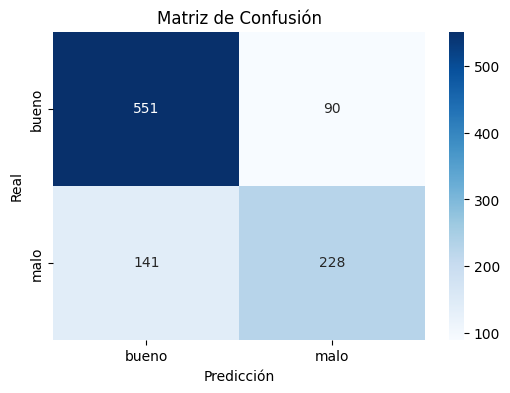

              precision    recall  f1-score   support

       bueno       0.80      0.86      0.83       641
        malo       0.72      0.62      0.66       369

    accuracy                           0.77      1010
   macro avg       0.76      0.74      0.75      1010
weighted avg       0.77      0.77      0.77      1010



In [30]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred, labels=['bueno', 'malo'])
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['bueno', 'malo'], yticklabels=['bueno', 'malo'])
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.title('Matriz de Confusión')
plt.show()

# Reporte
print(classification_report(y_test, y_pred))

### Interpretación de la Matriz de Confusión

La matriz de confusión muestra el rendimiento del modelo al clasificar vinos en dos categorías: **bueno** y **malo**.

**Resultados destacados:**
- ✅ **Verdaderos Positivos (malo correctamente clasificado):** 228
- ✅ **Verdaderos Negativos (bueno correctamente clasificado):** 551
- ❌ **Falsos Positivos (bueno clasificado como malo):** 90
- ❌ **Falsos Negativos (malo clasificado como bueno):** 141

**Conclusiones clave:**
- El modelo muestra un **buen rendimiento general**, especialmente clasificando vinos de buena calidad (bajo número de falsos positivos).
- 📌 Sin embargo, todavía existe un **número considerable de falsos negativos (141)**, lo que indica que el modelo podría mejorar la detección de vinos de mala calidad.

**Interpretación final:**  
El modelo es **fiable**, pero dependiendo del objetivo (minimizar falsos negativos o falsos positivos), puede ser ajustado. Aunque tras todo lo anterior podemos darlo por válido.


## Análisis de Importancia de Variables

Para interpretar el modelo Random Forest, analizamos la **importancia de las variables predictoras** mediante el atributo `feature_importances_`:

- ✅ Cada variable recibe un valor de importancia que refleja cuánto contribuye a la toma de decisiones del modelo.
- ✅ Visualizamos estas importancias usando un gráfico de barras, ordenadas según su peso relativo.
- ✅ Esto nos permite identificar:
   - Las **variables más influyentes** en la predicción de la calidad del vino,
   - Posibles características que podrían ser prescindibles o menos relevantes.

Este análisis es muy útil para:
- 📌 Mejorar la **interpretabilidad del modelo**,
- 📌 Tomar decisiones sobre posibles **reducciones de dimensionalidad**,
- 📌 Entender mejor qué características son determinantes en el contexto del negocio o problema analizado.


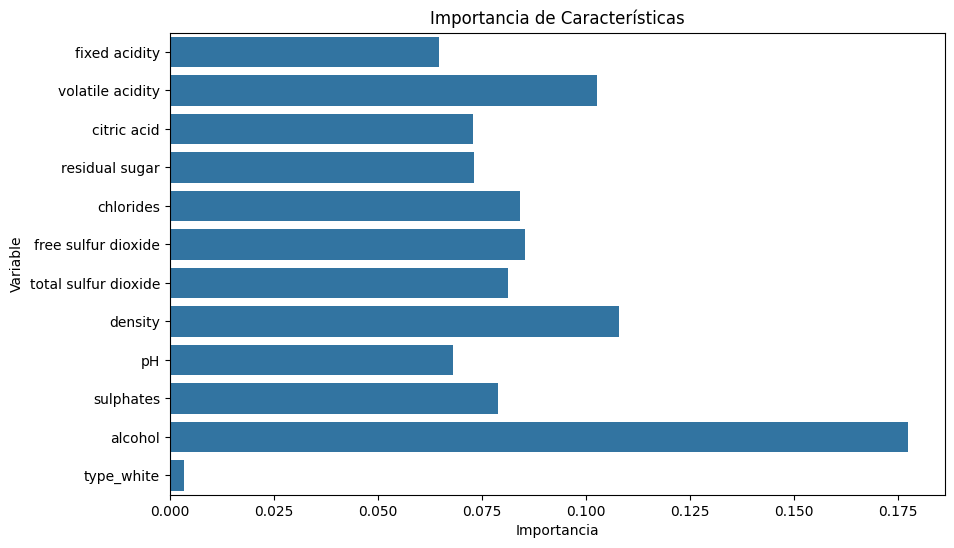

In [31]:
importances = modelo.feature_importances_
features = X.columns

plt.figure(figsize=(10, 6))
sns.barplot(x=importances, y=features)
plt.title('Importancia de Características')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.show()


### Interpretación - Importancia de Características

El gráfico muestra la **importancia relativa de cada variable predictiva** en la clasificación de la calidad del vino según el modelo Random Forest.

**Observaciones clave:**
- ✅ La variable **`alcohol`** es, con diferencia, la más influyente en la predicción de la calidad del vino.
- ✅ Otras variables relevantes incluyen:
   - **`volatile acidity`** y **`density`**, con un peso significativo,
   - Variables como **`citric acid`**, **`free sulfur dioxide`** y **`chlorides`** también aportan valor predictivo.
- ❗ La variable **`type_white`** (vino tinto o blanco) tiene **poca influencia directa** según este modelo.

**Conclusión:**
- Este análisis permite entender **qué características químicas son más determinantes** para el modelo al clasificar la calidad del vino.
- Esta información es útil para realizar futuras selecciones de variables o para **interpretar los factores clave** que afectan la calidad según los datos disponibles.


## Visualización con PCA (Análisis de Componentes Principales)

Para obtener una **visualización gráfica intuitiva** de la separación entre clases predichas, aplicamos **PCA (Principal Component Analysis)**:

- ✅ **PCA** es una técnica de reducción de dimensionalidad que transforma los datos a un espacio de menor dimensión, manteniendo la **mayor varianza posible**.
- ✅ En este caso, reducimos las variables a **2 componentes principales** para proyectarlas en un plano bidimensional.
- ✅ La gráfica resultante muestra:
   - Los puntos coloreados según la **clase real** (`hue=y_test`),
   - Y con diferentes estilos según la **predicción del modelo** (`style=y_pred`),
   - Permitiendo observar visualmente las zonas donde el modelo **acierta o falla**.

Este tipo de análisis visual ayuda a:
- 📌 Detectar **posibles agrupamientos naturales** en los datos,
- 📌 Identificar casos mal clasificados,
- 📌 Verificar gráficamente la **capacidad discriminativa del modelo**.


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: invalid value encountered in matmul
  X_transformed = X @ self.components_.T


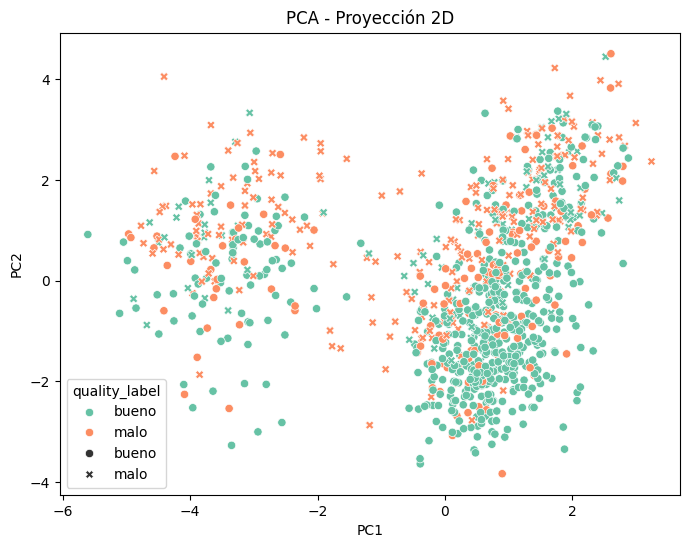

In [32]:
pca = PCA(n_components=2)
X_test_pca = pca.fit_transform(X_test_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_test_pca[:, 0], y=X_test_pca[:, 1], hue=y_test, style=y_pred, palette='Set2')
plt.title('PCA - Proyección 2D')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.show()

### 📌 Interpretación - Análisis PCA (Proyección en 2D)

La gráfica muestra la **proyección bidimensional** del conjunto de datos utilizando **PCA (Análisis de Componentes Principales)**.  
Mediante la reducción de dimensionalidad, se representan los registros en un plano formado por las dos primeras componentes principales (PC1 y PC2), que concentran la mayor parte de la variabilidad de los datos.

**Aspectos clave:**
- ✅ Los puntos están coloreados según la **clase real** (`bueno` o `malo`) y diferenciados con símbolos según la **predicción del modelo**.
- ✅ Podemos observar que el modelo logra una **cierta separación natural** entre ambas clases, aunque existen zonas de solapamiento.
- ✅ Este gráfico es útil para identificar visualmente:
   - Áreas donde las predicciones son más acertadas (agrupamientos homogéneos),
   - Áreas de mayor confusión, donde los puntos de diferentes clases se mezclan.

**Conclusión:**
- La **separación parcial entre clases** sugiere que las variables seleccionadas contienen información relevante para la predicción, aunque la **dispersión indica complejidad en la clasificación**, especialmente en las zonas intermedias.
- El PCA aporta una **visión global** de la estructura del dataset y del rendimiento del modelo en un espacio simplificado.


## Curvas ROC y Precision-Recall

En esta sección generamos las **curvas ROC** y **Precision-Recall**, que nos permiten evaluar gráficamente el rendimiento del modelo más allá de las métricas tradicionales como accuracy o F1-score.

- ✅ **Curva ROC (Receiver Operating Characteristic)**: muestra la relación entre la **tasa de verdaderos positivos (TPR)** y la **tasa de falsos positivos (FPR)**. Un área bajo la curva (AUC) más cercana a 1 indica un modelo con mejor capacidad discriminativa.

- ✅ **Curva Precision-Recall**: se enfoca especialmente en el comportamiento del modelo sobre la clase positiva (en este caso, la clase "malo"). Es útil cuando tenemos clases desbalanceadas porque muestra el compromiso entre **recall** (sensibilidad) y **precision** (exactitud).

Estas gráficas permiten:
- Visualizar la **robustez del modelo**.
- Identificar posibles problemas con falsos positivos o falsos negativos.
- Evaluar si el modelo se mantiene estable ante diferentes umbrales de decisión.

Al final, estas curvas ayudan a decidir si es necesario **ajustar el umbral** o aplicar **mejoras al modelo** para maximizar el rendimiento en función del objetivo del análisis.


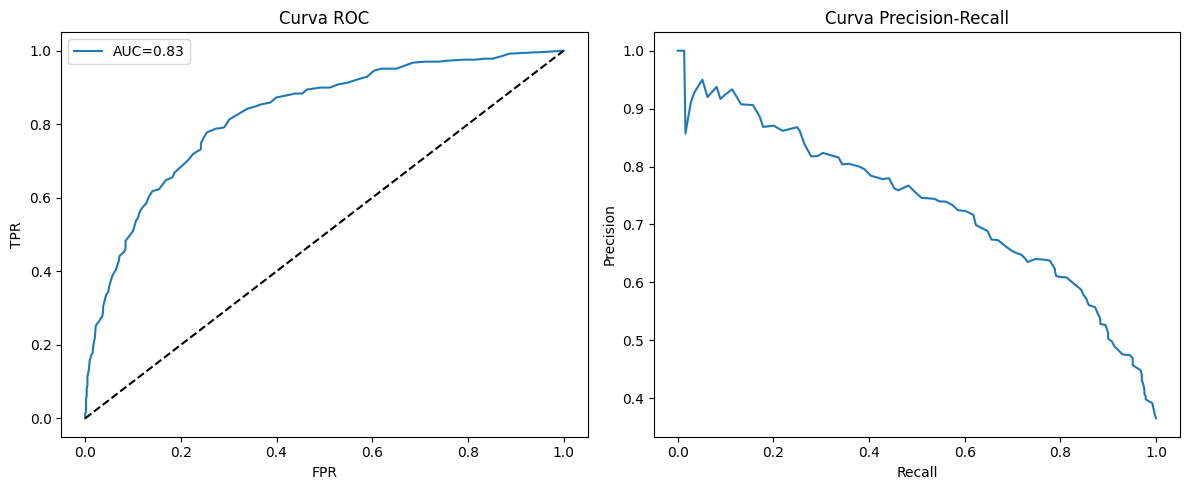

In [33]:
y_prob = modelo.predict_proba(X_test_scaled)[:,1]
le = LabelEncoder()
y_test_enc = le.fit_transform(y_test)

fpr, tpr, _ = roc_curve(y_test_enc, y_prob, pos_label=1)
precision, recall, _ = precision_recall_curve(y_test_enc, y_prob)

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(fpr, tpr, label=f"AUC={auc(fpr,tpr):.2f}")
plt.plot([0,1],[0,1],'k--')
plt.title("Curva ROC")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.legend()

plt.subplot(1,2,2)
plt.plot(recall, precision)
plt.title("Curva Precision-Recall")
plt.xlabel("Recall")
plt.ylabel("Precision")

plt.tight_layout()
plt.show()

### Análisis de Curvas ROC y Precision-Recall

Las gráficas muestran el rendimiento del modelo desde dos perspectivas complementarias:

#### ✅ Curva ROC (Receiver Operating Characteristic):
- Representa la relación entre el **True Positive Rate (TPR)** y el **False Positive Rate (FPR)**.
- El **AUC = 0.83** indica un **buen rendimiento global del modelo**, siendo significativamente superior al valor de referencia (0.5) que refleja un modelo aleatorio.
- Una curva más cercana al vértice superior izquierdo sugiere un mejor equilibrio entre sensibilidad y especificidad.

#### ✅ Curva Precision-Recall:
- Refleja la relación entre la **Precisión** y el **Recall** para diferentes umbrales de decisión.
- La gráfica muestra una **buena precisión (>0.8)** en rangos bajos y medios de recall, lo cual es valioso especialmente en datasets con cierto desbalance de clases.
- Permite analizar el comportamiento del modelo sobre la clase minoritaria (“malo”), siendo particularmente útil cuando nos interesa mejorar la **capacidad de detección sin sacrificar precisión**.

#### 📌 Conclusión General:
- El **AUC-ROC alto** confirma un rendimiento sólido y balanceado del modelo.
- La **curva Precision-Recall** sugiere que el modelo es fiable detectando “malo”, aunque se podría considerar un ajuste de umbral si el objetivo fuera priorizar aún más el recall.
